### Base frequency (positional encoding)

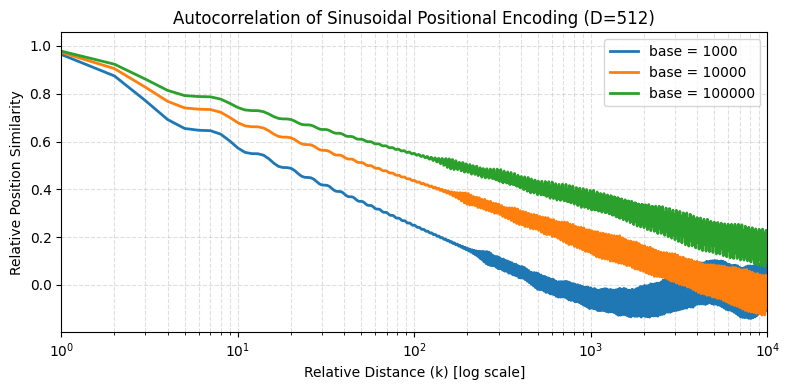

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
D = 512
base_frequencies = [1000, 10000, 100000]

# Only positive k for log scale
k = np.arange(0, 10001)

def compute_autocorrelation(k_vec, D_val, base_freq):
    i = np.arange(D_val // 2)
    omega = 1 / (base_freq ** (2 * i / D_val))
    cos_terms = np.cos(np.outer(k_vec, omega))
    return (2 / D_val) * np.sum(cos_terms, axis=1)

# Plot
plt.figure(figsize=(8, 4))

for bf in base_frequencies:
    R = compute_autocorrelation(k, D, bf)
    plt.plot(k, R, linewidth=2, label=f"base = {bf}")

plt.xscale('log')
plt.xlabel("Relative Distance (k) [log scale]")
plt.ylabel("Relative Position Similarity")
plt.title(f"Autocorrelation of Sinusoidal Positional Encoding (D={D})")

plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.xlim(1, 10000)
plt.legend()
plt.tight_layout()
plt.show()